In [1]:
import os, random
import numpy as np
from PIL import Image

PRED_DIR = "/home/scs_deal_projects_notapebackup/shared/DATASET/cityscapes/seg_eval_foggy_beta_0005/pred"
GT_DIR   = "/home/scs_deal_projects_notapebackup/shared/DATASET/cityscapes/seg_eval_foggy_beta_0005/gt"

names = [f for f in os.listdir(PRED_DIR) if f.endswith(".png")]
fn = random.choice(names)
print("Sample:", fn)

p = np.array(Image.open(os.path.join(PRED_DIR, fn)))
g = np.array(Image.open(os.path.join(GT_DIR, fn)))

print("pred shape:", p.shape, "gt shape:", g.shape)
print("unique pred labels:", np.unique(p))
print("unique gt labels:",   np.unique(g))


Sample: aachen_000101_000019_leftImg8bit_foggy_beta_0.005.png
pred shape: (1024, 2048) gt shape: (1024, 2048)
unique pred labels: [  0   1   5   6   8   9  10  11  12  13  15  18 255]
unique gt labels: [ 1  3  4  6  7  8 11 17 19 20 21 23 24 26 32 33]


In [2]:
from pathlib import Path

LABELS_FILE = Path("/home/scs_deal_projects_notapebackup/user/shubhang/thesis/sam_clip_full/configs/cityscapes_text_labels_19.txt")

with open(LABELS_FILE) as f:
    labels = [l.strip() for l in f if l.strip()]

for i, name in enumerate(labels):
    print(i, name)


0 the road surface
1 the sidewalk next to the road
2 urban building facades
3 a city wall or barrier
4 a fence along the road
5 a thin vertical pole
6 a traffic light at an intersection
7 a traffic sign on the street
8 trees and green vegetation
9 grass or ground terrain
10 the sky above the city
11 a walking person
12 a person riding a bike or motorcycle
13 a car on the road
14 a truck on the road
15 a bus on the road
16 a train on the tracks
17 a motorcycle on the road
18 a bicycle on the road


In [3]:
for i, name in enumerate(CITYSCAPES_CLASSES_19):
    print(i, name)


NameError: name 'CITYSCAPES_CLASSES_19' is not defined

Image size (from file): (4096, 4096)
Image size (from JSON): (4096, 4096)
Image name (from path): frame00000_Probe00000.png
Image name (from JSON): frame00000_Probe00000.png
Measurement (from JSON): record18-LVP-Vollstrom

Found 7 masks in annotation.

--------------------------------------------------------------------------------
Mask #0
mask id: 21c3d091-3354-4862-ac83-81032ee2cb93
Labels: Verpackungsform - Packaging Form: Flasche-Bottle; Transparent: Nein-No; Beklebt - Stickered: Beklebt-Stickered
Mask foreground pixels: 314151


IndexError: boolean index did not match indexed array along axis 2; size of axis is 3 but size of corresponding boolean axis is 1

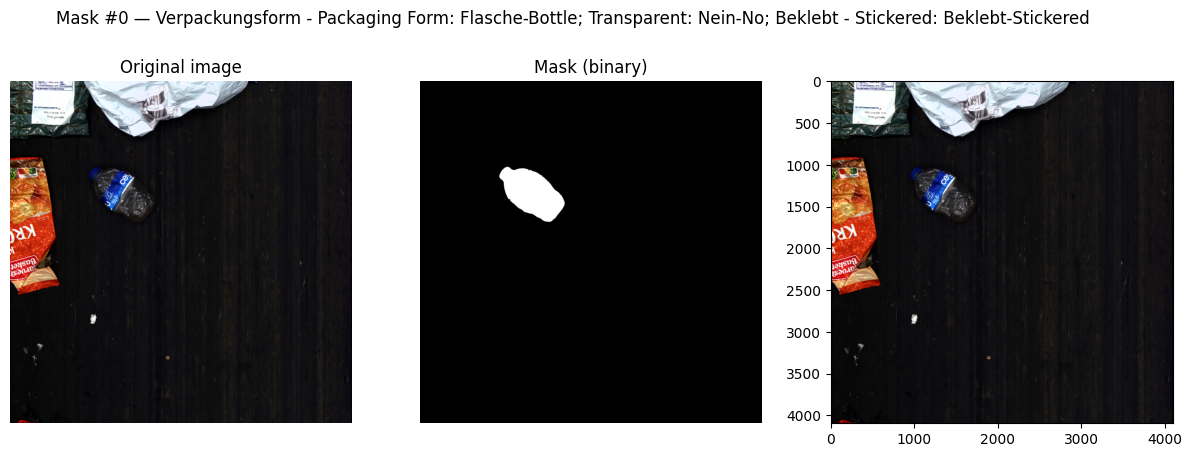

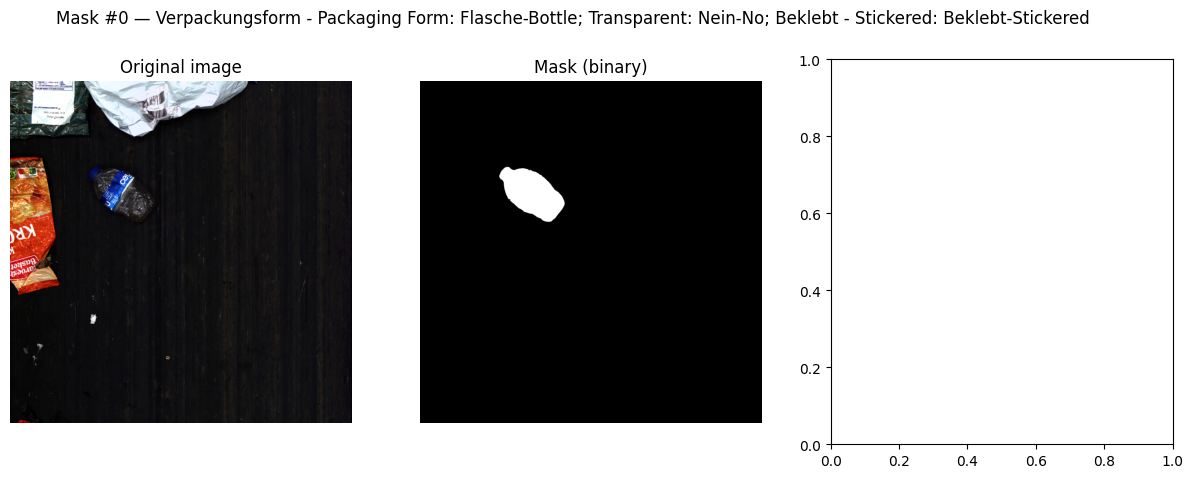

In [4]:
import json
from pathlib import Path

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from label_studio_converter.brush import decode_rle

# --- paths (adjust if needed) ---
IMAGE_PATH = "/home/scs_deal_projects_notapebackup/projects/R003/dataset/lobbe/record18-LVP-Vollstrom/frame00000_Probe00000.png"
ANN_PATH   = "/home/scs_deal_projects_notapebackup/projects/R003/dataset/lobbe/annotations/record18-LVP-Vollstrom/frame00000_Probe00000.json"


# ---------- 1. Load image & annotation ----------
img = Image.open(IMAGE_PATH).convert("RGB")
img_w, img_h = img.size

with open(ANN_PATH, "r") as f:
    ann = json.load(f)

print("Image size (from file):", (img_w, img_h))
print("Image size (from JSON):", (ann["image_width"], ann["image_height"]))
print("Image name (from path):", Path(IMAGE_PATH).name)
print("Image name (from JSON):", ann["image_name"])
print("Measurement (from JSON):", ann.get("measurement"))

# Basic consistency checks
assert ann["image_width"] == img_w,  "Width mismatch between image and JSON"
assert ann["image_height"] == img_h, "Height mismatch between image and JSON"
assert ann["image_name"] == Path(IMAGE_PATH).name, "Filename mismatch between image and JSON"

masks = ann["masks"]
print(f"\nFound {len(masks)} masks in annotation.")


# ---------- 2. Helper to pretty-print the label tree ----------
def flatten_label_tree(label_tree: dict) -> str:
    """
    Turn the 'label tree' dict into a human-readable label string.
    Only keep keys that actually have a value.
    """
    parts = []
    for key, values in label_tree.items():
        if values:  # non-empty list
            parts.append(f"{key}: {', '.join(values)}")
    return "; ".join(parts) if parts else "(no labels)"


# ---------- 3. Decode and visualize each mask ----------
for idx, mask_entry in enumerate(masks):
    print("\n" + "-" * 80)
    print(f"Mask #{idx}")
    print("mask id:", mask_entry.get("mask id"))

    # Get label info
    ann_list = mask_entry.get("annotations", [])
    if len(ann_list) > 0:
        label_tree = ann_list[0].get("label tree", {})
        label_desc = flatten_label_tree(label_tree)
    else:
        label_tree = {}
        label_desc = "(no labels)"
    print("Labels:", label_desc)

    # Decode RLE -> flat array
    rle = mask_entry["mask"]
    mask_flat = decode_rle(rle)  # 1D array

    # Reshape to [H, W, 4] and take alpha channel (like in brush.py)
    mask_img = mask_flat.reshape(ann["image_height"], ann["image_width"], 4)[:, :, 3]

    # Binarize: anything >0 is foreground
    mask_binary = (mask_img > 0).astype(np.uint8)
    area = int(mask_binary.sum())
    print("Mask foreground pixels:", area)

    # --- visualize: image, mask, and overlay ---
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Mask #{idx} — {label_desc}", fontsize=12)

    # 1) original image
    axes[0].imshow(img)
    axes[0].set_title("Original image")
    axes[0].axis("off")

    # 2) raw mask
    axes[1].imshow(mask_binary, cmap="gray")
    axes[1].set_title("Mask (binary)")
    axes[1].axis("off")

    # 3) overlay
    axes[2].imshow(img)
    # apply masked overlay
        # --- visualize: image, mask, and overlay ---
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Mask #{idx} — {label_desc}", fontsize=12)

    # 1) original image
    axes[0].imshow(img)
    axes[0].set_title("Original image")
    axes[0].axis("off")

    # 2) raw mask
    axes[1].imshow(mask_binary, cmap="gray")
    axes[1].set_title("Mask (binary)")
    axes[1].axis("off")

    # 3) overlay: paint red where mask == 1
    img_np = np.array(img).astype(np.float32) / 255.0   # (H, W, 3)
    overlay = img_np.copy()
    red = np.array([1.0, 0.0, 0.0], dtype=np.float32)   # pure red

    # broadcast mask to 3 channels: (H, W, 1) -> (H, W, 3)
    m = mask_binary[..., None].astype(bool)

    # blend red with original image where mask is 1
    overlay[m] = 0.7 * overlay[m] + 0.3 * red

    axes[2].imshow(overlay)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()



In [2]:
!pip install label_studio_converter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 41.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 25.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [label_studio_converter]_studio_converter]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
